Деректердің бастапқы өлшемі: (344, 7)
--------------------------------------------------
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

---- Деректер типі туралы ақпарат ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 

/tmp/ipython-input-3305924296.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3305924296.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

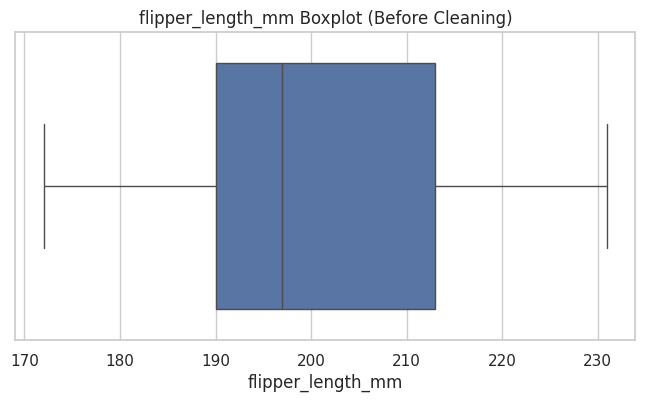


Ауытқулар тазартылғаннан кейінгі деректер өлшемі: (344, 7)


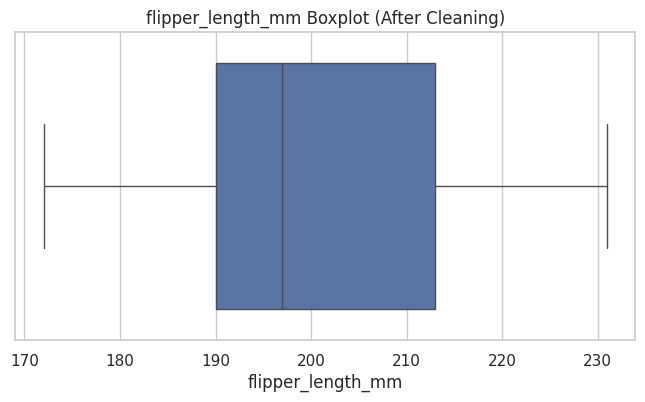

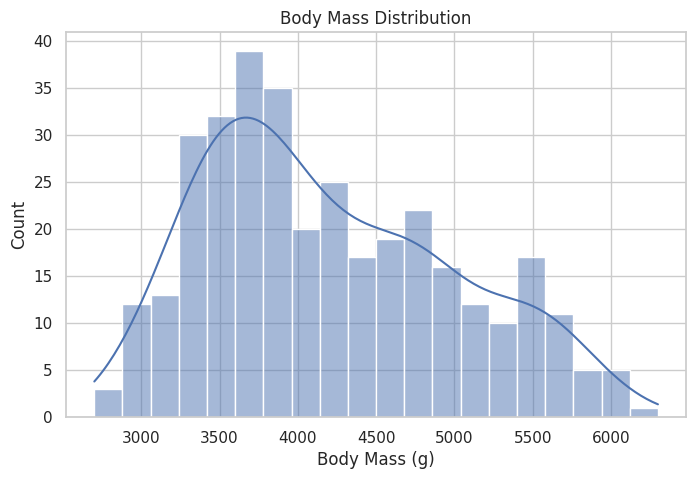

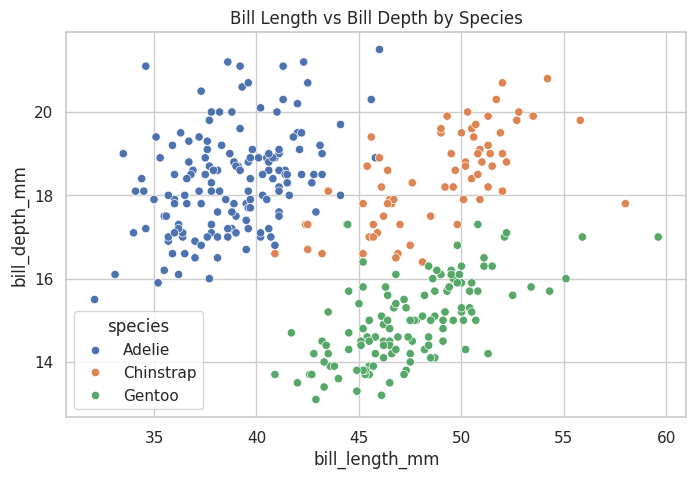

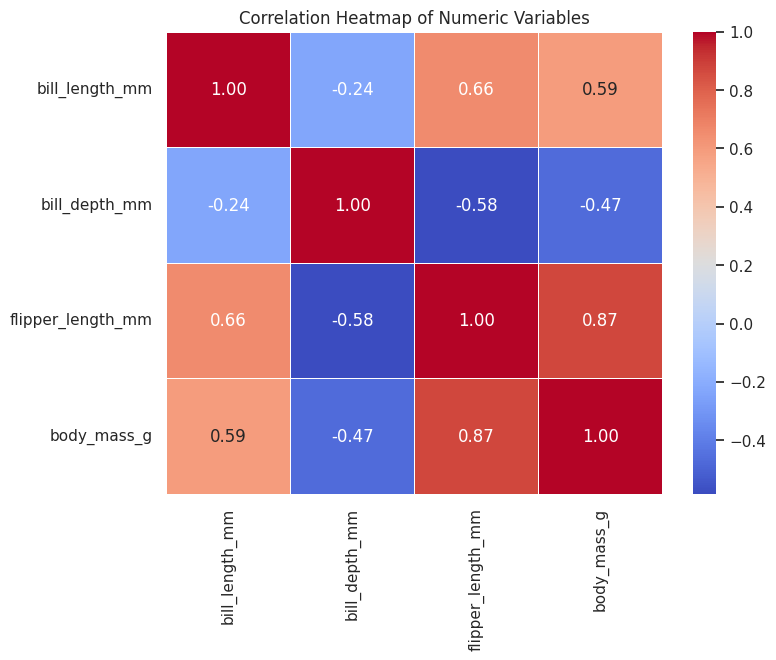


Feature Engineering нәтижесі:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen           39.10           18.7              181.0   
1  Adelie  Torgersen           39.50           17.4              186.0   
2  Adelie  Torgersen           40.30           18.0              195.0   
3  Adelie  Torgersen           44.45           17.3              197.0   
4  Adelie  Torgersen           36.70           19.3              193.0   

   body_mass_g     sex  bill_ratio  
0       3750.0    Male    2.090909  
1       3800.0  Female    2.270115  
2       3250.0  Female    2.238889  
3       4050.0    Male    2.569364  
4       3450.0  Female    1.901554  

Encoding нәтижесі:
   species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0        0           39.10           18.7              181.0       3750.0   
1        0           39.50           17.4              186.0       3800.0   
2        0           40.30           18.0          

In [1]:
# =======================================================
# 🐧 0. Кіріспе
# =======================================================

# Атауы: Palmer Penguins деректер жинағына EDA және Feature Engineering
# Мақсаты: Деректерді тазарту, өңдеу және модельдеуге дайындау.

# =======================================================
# 1. Кітапханаларды және деректерді жүктеу
# =======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Визуализация параметрлерін орнату
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Деректер жинағын жүктеу
df = sns.load_dataset('penguins')

print(f"Деректердің бастапқы өлшемі: {df.shape}")
print("-" * 50)
print(df.head())


# =======================================================
# 2. Деректерді шолу және Тазарту (Data Cleaning)
# =======================================================

# 1. Деректер туралы ақпарат (info)
print("\n---- Деректер типі туралы ақпарат ----")
df.info()

# 2. Бос мәндер санын тексеру
print("\n---- Бос мәндер (NaN) саны ----")
print(df.isnull().sum())

# 3. Бос мәндерді толтыру
# Сандық бағандарды медианамен толтыру
num_cols_to_fill = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in num_cols_to_fill:
    df[col].fillna(df[col].median(), inplace=True)

# 'sex' бағанын (санаттық) модамен толтыру
mode_sex = df['sex'].mode()[0]
df['sex'].fillna(mode_sex, inplace=True)

# Тексеру: Бос мәндер қалмағанына көз жеткізіңіз
print("\n---- Тазартылғаннан кейінгі бос мәндер ----")
print(df.isnull().sum())


# =======================================================
# 3. Ауытқуларды анықтау және өңдеу (Outlier Handling)
# =======================================================

col_name = 'flipper_length_mm'

# Boxplot салу (Тазарту алдында)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[col_name])
plt.title(f'{col_name} Boxplot (Before Cleaning)')
plt.show()

# IQR және шектік мәндерді есептеу
Q1 = df[col_name].quantile(0.25)
Q3 = df[col_name].quantile(0.75)
IQR = Q3 - Q1
# 1.5 IQR ережесі
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ауытқуларды алып тастау
df = df[(df[col_name] >= lower_bound) & (df[col_name] <= upper_bound)]

print(f"\nАуытқулар тазартылғаннан кейінгі деректер өлшемі: {df.shape}")

# Тексеру: Boxplot салу (Тазартудан кейін)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[col_name])
plt.title(f'{col_name} Boxplot (After Cleaning)')
plt.show()


# =======================================================
# 4. Визуализация (EDA)
# =======================================================

# 1. Салмақтың таралуы (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['body_mass_g'], kde=True, bins=20)
plt.title('Body Mass Distribution')
plt.xlabel('Body Mass (g)')
plt.show()

# 2. Scatterplot: Тұмсық ұзындығы vs Тереңдігі
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', hue='species', data=df)
plt.title('Bill Length vs Bill Depth by Species')
plt.show()

# 3. Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


# =======================================================
# 5. Feature Engineering
# =======================================================

# Жаңа 'bill_ratio' белгісін жасау
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']

print("\nFeature Engineering нәтижесі:")
print(df.head())


# =======================================================
# 6. Санаттық белгілерді кодтау (Encoding)
# =======================================================

# 1. Label Encoding (species - нысана айнымалысы)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# 2. One-Hot Encoding (island, sex)
categorical_cols = ['island', 'sex']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nEncoding нәтижесі:")
print(df_encoded.head())


# =======================================================
# 7. Шкалалау (Scaling)
# =======================================================

scaler = StandardScaler()

# Шкалаланатын бағандар тізімі
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'bill_ratio']

# Шкалалауды жүзеге асыру
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\nStandard Scaling нәтижесі:")
print(df_encoded.head())